# Final Gemma 4

In [10]:
import polars as pl

from social_groups.analysis.defs.notebooks.definitions import register_materialization
from social_groups.analysis.polars_transformations import (
    apply_parsing_and_group_decision,
)
from social_groups.analysis.polars_transformations.wasserstein_distance import (
    calculate_wasserstein_distance,
)
from social_groups.reporting.group_reply import (
    GroupReplyAggregator,
    MajorityVote,
)
import social_groups.polars_columns as plc
from social_groups.reporting.parsing import (
    AnswerComparer,
    AnswerOptions,
    AnswerParser,
)

In [11]:
parser = AnswerParser(AnswerOptions.letters_A_to_D)
group_reply = GroupReplyAggregator(MajorityVote())
comparer = AnswerComparer(
    AnswerOptions.letters_A_to_D, triple_underscore_handling="wrong"
)

In [12]:
from social_groups.analysis.definitions import defs

gemma4_single_model_baseline: pl.DataFrame = defs().load_asset_value(
    "final_gemma4_single_model_baseline"
)
gemma4_no_discussion_voting: pl.DataFrame = defs().load_asset_value(
    "final_gemma4_no_discussion_voting_base"
)
gemma4_multi_agent_debate: pl.DataFrame = defs().load_asset_value(
    "final_gemma4_multi_agent_debateV2"
)

2026-07-11 12:01:43 +0200 - dagster - DEBUG - system - Loading file from: /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/final_gemma4_single_model_baseline.parquet using PolarsParquetIOManager...
2026-07-11 12:01:43 +0200 - dagster - DEBUG - system - Loading file from: /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/final_gemma4_no_discussion_voting_base.parquet using PolarsParquetIOManager...
2026-07-11 12:01:44 +0200 - dagster - DEBUG - system - Loading file from: /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/final_gemma4_multi_agent_debateV2.parquet using PolarsParquetIOManager...


In [13]:
gemma4_multi_agent_debate = apply_parsing_and_group_decision(
    gemma4_multi_agent_debate, parser, comparer, group_reply
)
gemma4_no_discussion_voting = gemma4_no_discussion_voting.with_columns(
    parser(pl.col(plc.final_answer)).alias("parsed_answer")
).drop(
    "phoenix_span_url",
    "run_identifier",
    "question_id",
    "category",
    "question",
    "with_few_shot_prompting",
    "use_thinking",
    "max_new_tokens",
    "final_answer",
    "temperature",
    "top_p",
    "model_name",
)

gemma4_single_model_baseline = (
    gemma4_single_model_baseline.with_columns(
        parser(pl.col(plc.final_answer)).alias("parsed_answer")
    )
    .with_columns(
        comparer(pl.col("parsed_answer"), pl.col(plc.answer_string)).alias(
            plc.is_correct
        )
    )
    .drop(
        "phoenix_span_url",
        "run_identifier",
        "final_answer",
        "question_id",
        "category",
        "question",
        "with_few_shot_prompting",
        "use_thinking",
        "max_new_tokens",
        "temperature",
        "top_p",
        "model_name",
    )
)

In [14]:
single_model_result = gemma4_single_model_baseline.group_by("seed", "model_size").agg(
    pl.col("used_input_tokens").mean(),
    pl.col("used_output_tokens").mean(),
    accuracy=pl.col("is_correct").mean(),
)
single_model_result

seed,model_size,used_input_tokens,used_output_tokens,accuracy
i64,str,f64,f64,f64
3,"""E4B""",245.045455,1681.636364,0.535354
2,"""31B""",249.045455,744.722222,0.762626
1,"""31B""",249.045455,772.757576,0.762626
4,"""E4B""",245.045455,1738.19697,0.545455
4,"""E2B""",245.045455,1530.631313,0.40404
…,…,…,…,…
2,"""E4B""",245.045455,1649.707071,0.570707
2,"""E2B""",245.045455,1516.712121,0.39899
5,"""E4B""",245.045455,1735.383838,0.510101


In [15]:
import polars as pl


no_discussion_result = (
    gemma4_no_discussion_voting.group_by("seed", "model_size", "original_question_id")
    .agg(
        pl.col("answer_string").unique().item(),
        pl.col("parsed_answer").alias("parsed_answers"),
        pl.col("used_input_tokens").alias("used_input_tokensS"),
        pl.col("used_output_tokens").alias("used_output_tokensS"),
    )
    .join(
        pl.DataFrame({"no_participants": range(1, 10)}),
        how="cross",
    )
    .with_columns(
        group_answer=group_reply(
            pl.col("parsed_answers").list.slice(0, pl.col("no_participants"))
        ),
        used_input_tokens=pl.col("used_input_tokensS")
        .list.slice(0, pl.col("no_participants"))
        .list.sum(),
        used_output_tokens=pl.col("used_output_tokensS")
        .list.slice(0, pl.col("no_participants"))
        .list.sum(),
    )
    .with_columns(is_correct=comparer(pl.col("group_answer"), pl.col("answer_string")))
    .group_by("seed", "model_size", "no_participants")
    .agg(
        pl.col("used_input_tokens").mean(),
        pl.col("used_output_tokens").mean(),
        accuracy=pl.col("is_correct").mean(),
    )
)

no_discussion_result

seed,model_size,no_participants,used_input_tokens,used_output_tokens,accuracy
i64,str,i64,f64,f64,f64
3,"""E2B""",9,2205.409091,13774.843434,0.414141
5,"""E2B""",4,980.181818,6132.39899,0.348485
2,"""E2B""",5,1225.227273,7550.909091,0.39899
2,"""E2B""",2,490.090909,2993.944444,0.313131
5,"""E4B""",1,245.045455,1761.116162,0.555556
…,…,…,…,…,…
5,"""E4B""",4,980.181818,7027.656566,0.545455
5,"""E4B""",3,735.136364,5280.838384,0.550505
3,"""E2B""",6,1470.272727,9141.555556,0.393939


In [38]:
mad_result = (
    gemma4_multi_agent_debate.drop(
        [
            "question_id",
            "category",
            "with_few_shot_prompting",
            "max_new_tokens",
            "top_p",
            "temperature",
            "model_names",
        ]
    )
    .group_by("seed", "model_sizes", "group_constellation", "thinking_openly")
    .agg(
        comparer(pl.col(plc.parsed_combined_answers_before), pl.col(plc.answer_string))
        .mean()
        .alias("accuracy_before"),
        comparer(pl.col(plc.parsed_combined_answers_after), pl.col(plc.answer_string))
        .mean()
        .alias("accuracy"),
        pl.col("used_input_tokens").mean(),
        pl.col("used_output_tokens").mean(),
        pl.col("run_identifier")
        .implode()
        .list.eval(pl.element().str.split("_").list.last().cast(pl.Int64))
        .list.min(),
        pl.col("phoenix_span_url").first(),
    )
    .with_columns(accuracy_increase=pl.col("accuracy") - pl.col("accuracy_before"))
)

In [18]:
(
    single_model_result.group_by("model_size").agg(
        pl.exclude("seed").mean().name.suffix("_mean"),
        pl.exclude("seed").std().name.suffix("_std"),
    )
)

model_size,used_input_tokens_mean,used_output_tokens_mean,accuracy_mean,used_input_tokens_std,used_output_tokens_std,accuracy_std
str,f64,f64,f64,f64,f64,f64
"""E2B""",245.045455,1528.938384,0.39596,0.0,16.070207,0.021007
"""31B""",249.045455,757.274747,0.766667,0.0,11.373146,0.009715
"""E4B""",245.045455,1703.159596,0.540404,0.0,37.569766,0.021723


In [19]:
(
    no_discussion_result.group_by("model_size", "no_participants").agg(
        pl.exclude("seed").mean().name.suffix("_mean"),
        pl.exclude("seed").std().name.suffix("_std"),
    )
)

model_size,no_participants,used_input_tokens_mean,used_output_tokens_mean,accuracy_mean,used_input_tokens_std,used_output_tokens_std,accuracy_std
str,i64,f64,f64,f64,f64,f64,f64
"""E4B""",5,1225.227273,8617.618182,0.541414,0.0,187.731141,0.014015
"""E4B""",7,1715.318182,12089.737374,0.556566,0.0,242.423728,0.016902
"""E2B""",7,1715.318182,10650.777778,0.393939,0.0,84.085745,0.007142
"""E4B""",6,1470.272727,10352.70202,0.529293,0.0,214.833293,0.017275
"""E2B""",3,735.136364,4550.3,0.378788,0.0,39.825204,0.014725
…,…,…,…,…,…,…,…
"""E4B""",3,735.136364,5163.533333,0.553535,0.0,109.370482,0.019099
"""E2B""",5,1225.227273,7580.511111,0.389899,0.0,41.576462,0.014015
"""E4B""",1,245.045455,1713.829293,0.558586,0.0,40.732903,0.022473


In [39]:
(
    mad_result.group_by("group_constellation", "thinking_openly").agg(
        pl.exclude("seed").mean().name.suffix("_mean"),
        pl.exclude("seed").std().name.suffix("_std"),
        pl.col("run_identifier").min(),
        pl.col("phoenix_span_url").first(),
    )
)

group_constellation,thinking_openly,model_sizes_mean,accuracy_before_mean,accuracy_mean,used_input_tokens_mean,used_output_tokens_mean,run_identifier_mean,phoenix_span_url_mean,accuracy_increase_mean,model_sizes_std,accuracy_before_std,accuracy_std,used_input_tokens_std,used_output_tokens_std,run_identifier_std,phoenix_span_url_std,accuracy_increase_std,run_identifier,phoenix_span_url
str,str,list[str],f64,f64,f64,f64,f64,str,f64,list[str],f64,f64,f64,f64,f64,str,f64,i64,str
"""HHL""","""only_H""",null,0.522222,0.562626,28705.693939,10139.519192,78.0,null,0.040404,null,0.016209,0.023309,347.318588,148.228593,44.271887,null,0.014725,22,"""http://localhost:46001/project…"
"""HH""","""only_H""",null,0.448485,0.541414,18653.454545,6820.572727,46.0,null,0.092929,null,0.016902,0.006585,288.647594,113.659553,25.298221,null,0.01317,14,"""http://localhost:46001/project…"
"""LL""","""only_H""",null,0.292929,0.362626,7320.947475,6378.319192,34.0,null,0.069697,null,0.017495,0.026581,82.543295,111.462295,25.298221,null,0.018349,2,"""http://localhost:46001/project…"
"""HHL""","""all""",null,0.516162,0.560606,35375.221212,10056.642424,79.0,null,0.044444,null,0.02682,0.018557,391.440174,194.270661,44.271887,null,0.022978,23,"""http://localhost:46001/project…"
"""LHH""","""nobody""",null,0.50202,0.537374,11844.705051,10539.537374,68.0,null,0.035354,null,0.009175,0.015402,120.028093,154.360246,44.271887,null,0.010101,12,"""http://localhost:46001/project…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""LHH""","""all""",null,0.494949,0.553535,34482.372727,9717.334343,71.0,null,0.058586,null,0.021723,0.01455,193.2759,97.260041,44.271887,null,0.026146,15,"""http://localhost:46001/project…"
"""HH""","""nobody""",null,0.439394,0.518182,8064.783838,7219.591919,44.0,null,0.078788,null,0.010101,0.015402,78.466978,90.569003,25.298221,null,0.017713,12,"""http://localhost:46001/project…"
"""HL""","""only_L""",null,0.315152,0.462626,12509.591919,6719.59697,41.0,null,0.147475,null,0.009845,0.016209,162.676835,144.726968,25.298221,null,0.015319,9,"""http://localhost:46001/project…"


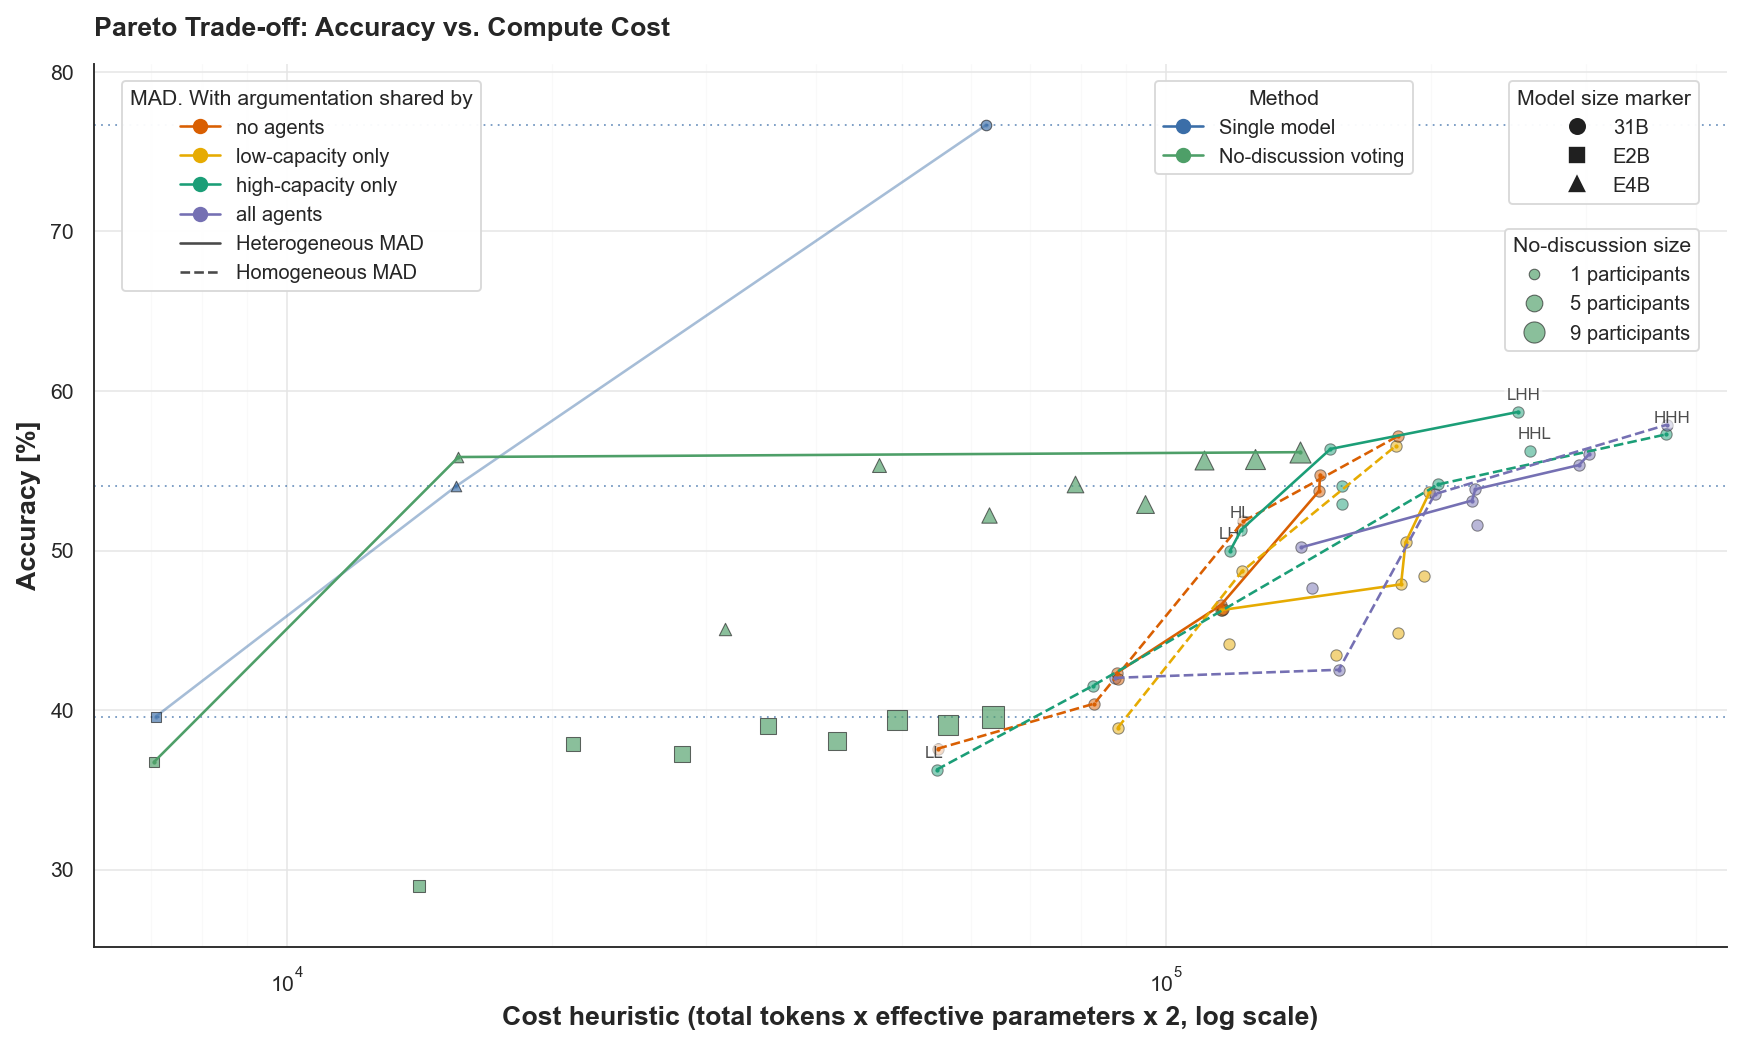

In [69]:
import re
import ast
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


sns.set_theme(
    context="paper",
    style="whitegrid",
    font_scale=1.18,
    rc={
        "figure.dpi": 170,
        "savefig.dpi": 320,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": "#2A2A2A",
        "axes.linewidth": 0.8,
        "axes.titleweight": "bold",
        "axes.labelweight": "bold",
        "grid.color": "#E5E5E5",
        "grid.linewidth": 0.7,
        "legend.frameon": True,
        "legend.facecolor": "white",
        "legend.edgecolor": "#D8D8D8",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    },
)

PARAMS_BILLIONS = {
    "E2B": 2,
    "E4B": 4,
    "31B": 31,
}

METHOD_ORDER = [
    "Single Model",
    "No Discussion",
    "MAD",
]

BASE_METHOD_COLORS = {
    "Single Model": "#3B6EA8",
    "No Discussion": "#4E9F68",
}

MAD_ARGUMENT_SHARING_ORDER = ["nobody", "only_L", "only_H", "all"]
MAD_ARGUMENT_SHARING_LABELS = {
    "all": "all agents",
    "nobody": "no agents",
    "only_H": "high-capacity only",
    "only_L": "low-capacity only",
}
MAD_ARGUMENT_SHARING_COLORS = {
    "nobody": "#D95F02",
    "only_L": "#E6AB02",
    "only_H": "#1B9E77",
    "all": "#7570B3",
}
MAD_COMPOSITION_LINESTYLES = {
    "heterogeneous": "-",
    "homogeneous": "--",
}

MARKERS = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*", "h"]
PARETO_MARKER_SIZE = 0.8
PARETO_LINEWIDTH = 1.1
MAD_POINT_SIZE = 23
EXPECTED_RESULTS_PER_POINT = 5
MAD_LABEL_ARGUMENT_SHARING = "only_H"
MAD_LABEL_CONSTELLATIONS = {"HHL", "LHH", "LL", "HHH", "HL", "LH"}


def extract_model_sizes(value):
    if isinstance(value, (list, tuple)):
        raw = " ".join(map(str, value))
    else:
        raw = str(value)

    try:
        parsed = ast.literal_eval(raw)
        if isinstance(parsed, (list, tuple)):
            raw = " ".join(map(str, parsed))
    except Exception:
        pass

    models = re.findall(r"(E2B|E4B|31B)", raw)

    if not models:
        raise ValueError(f"Could not infer model size from: {value}")

    return models


def model_params_sum(value):
    return sum(PARAMS_BILLIONS[m] for m in extract_model_sizes(value))


def model_params_average(value):
    return np.mean([PARAMS_BILLIONS[m] for m in extract_model_sizes(value)])


def argument_sharing_label(value):
    return MAD_ARGUMENT_SHARING_LABELS.get(str(value), str(value).replace("_", " "))


def mad_composition_type(value):
    letters = re.findall(r"[A-Z]", str(value))
    if letters and len(set(letters)) == 1:
        return "homogeneous"
    return "heterogeneous"


def bootstrap_ci(values, statistic=np.mean, n_boot=5000, ci=95, seed=42):
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]

    if len(values) == 0:
        return np.nan, np.nan

    if len(values) == 1:
        stat = statistic(values)
        return stat, stat

    rng = np.random.default_rng(seed)
    samples = rng.choice(values, size=(n_boot, len(values)), replace=True)
    stats = np.apply_along_axis(statistic, 1, samples)

    alpha = (100 - ci) / 2
    return np.percentile(stats, alpha), np.percentile(stats, 100 - alpha)


def to_pandas(df):
    return df.to_pandas() if isinstance(df, pl.DataFrame) else df.copy()


def model_shape_key(frame):
    if "model_type" in frame.columns and "model_size" in frame.columns:
        return frame["model_type"].astype(str) + " " + frame["model_size"].astype(str)
    if "model_size" in frame.columns:
        return frame["model_size"].astype(str)
    if "model_sizes" in frame.columns:
        return frame["model_sizes"].astype(str)
    return "model"


def prepare_pareto_results(
    mad_result,
    no_discussion_result,
    single_model_result,
):
    single = to_pandas(single_model_result)
    single["method"] = "Single Model"
    single["setting"] = model_shape_key(single)
    single["shape_key"] = model_shape_key(single)
    single["thinking_openly"] = "Single Model"
    single["argument_sharing"] = ""
    single["argument_sharing_label"] = ""
    single["group_constellation"] = ""
    single["mad_composition"] = ""
    single["no_participants"] = 1
    single["effective_params_b"] = single["model_size"].apply(model_params_sum)

    nodisc = to_pandas(no_discussion_result)
    nodisc["method"] = "No Discussion"
    nodisc["shape_key"] = model_shape_key(nodisc)
    nodisc["setting"] = (
        nodisc["shape_key"].astype(str) + " x " + nodisc["no_participants"].astype(str)
    )
    nodisc["thinking_openly"] = "No Discussion"
    nodisc["argument_sharing"] = ""
    nodisc["argument_sharing_label"] = ""
    nodisc["group_constellation"] = ""
    nodisc["mad_composition"] = ""
    nodisc["effective_params_b"] = nodisc["model_size"].apply(model_params_sum)

    mad = to_pandas(mad_result)
    mad["method"] = "MAD"
    mad["setting"] = mad["group_constellation"].astype(str)
    mad["shape_key"] = "MAD"
    mad["argument_sharing"] = mad["thinking_openly"].astype(str)
    mad["argument_sharing_label"] = mad["argument_sharing"].apply(
        argument_sharing_label
    )
    mad["mad_composition"] = mad["group_constellation"].apply(mad_composition_type)
    mad["no_participants"] = np.nan
    mad["effective_params_b"] = mad["model_sizes"].apply(model_params_average)

    common_cols = [
        "seed",
        "method",
        "setting",
        "shape_key",
        "thinking_openly",
        "argument_sharing",
        "argument_sharing_label",
        "group_constellation",
        "mad_composition",
        "no_participants",
        "accuracy",
        "used_input_tokens",
        "used_output_tokens",
        "effective_params_b",
    ]

    df = pd.concat(
        [
            single[common_cols],
            nodisc[common_cols],
            mad[common_cols],
        ],
        ignore_index=True,
    )

    df["total_tokens"] = df["used_input_tokens"] + df["used_output_tokens"]
    df["cost"] = df["total_tokens"] * df["effective_params_b"] * 2
    df["accuracy_pct"] = 100 * df["accuracy"]

    return df


def aggregate_for_pareto_plotting(df, n_boot=5000):
    rows = []

    group_cols = [
        "method",
        "setting",
        "shape_key",
        "thinking_openly",
        "argument_sharing",
        "argument_sharing_label",
        "group_constellation",
        "mad_composition",
        "no_participants",
    ]

    for keys, part in df.groupby(group_cols, dropna=False):
        (
            method,
            setting,
            shape_key,
            thinking_openly,
            argument_sharing,
            argument_sharing_label,
            group_constellation,
            mad_composition,
            no_participants,
        ) = keys

        n_rows = len(part)
        n_seeds = part["seed"].nunique()
        if n_rows != EXPECTED_RESULTS_PER_POINT or n_seeds != EXPECTED_RESULTS_PER_POINT:
            raise AssertionError(
                "Each plotted point must aggregate exactly "
                f"{EXPECTED_RESULTS_PER_POINT} seed results, but "
                f"{method} / {setting} has {n_rows} rows and {n_seeds} seeds."
            )

        acc_low, acc_high = bootstrap_ci(
            part["accuracy_pct"],
            n_boot=n_boot,
        )

        cost_low, cost_high = bootstrap_ci(
            part["cost"],
            n_boot=n_boot,
        )

        rows.append(
            {
                "method": method,
                "setting": setting,
                "shape_key": shape_key,
                "thinking_openly": thinking_openly,
                "argument_sharing": argument_sharing,
                "argument_sharing_label": argument_sharing_label,
                "group_constellation": group_constellation,
                "mad_composition": mad_composition,
                "no_participants": no_participants,
                "accuracy_mean": part["accuracy"].mean(),
                "accuracy_pct_mean": part["accuracy_pct"].mean(),
                "accuracy_pct_low": acc_low,
                "accuracy_pct_high": acc_high,
                "cost_mean": part["cost"].mean(),
                "cost_low": cost_low,
                "cost_high": cost_high,
                "total_tokens_mean": part["total_tokens"].mean(),
                "effective_params_b_mean": part["effective_params_b"].mean(),
                "n_seeds": n_seeds,
            }
        )

    agg = pd.DataFrame(rows)
    agg["method"] = pd.Categorical(
        agg["method"],
        categories=METHOD_ORDER,
        ordered=True,
    )

    return agg.sort_values(["method", "cost_mean"])


def pareto_front(df, cost_col="cost_mean", perf_col="accuracy_pct_mean"):
    d = df.sort_values([cost_col, perf_col], ascending=[True, False]).copy()

    best_so_far = -np.inf
    keep = []

    for _, row in d.iterrows():
        if row[perf_col] > best_so_far:
            keep.append(True)
            best_so_far = row[perf_col]
        else:
            keep.append(False)

    return d.loc[keep].copy()


def marker_size_from_participants(
    value,
    observed_values=None,
    min_size=20,
    max_size=80,
):
    if pd.isna(value):
        return MAD_POINT_SIZE

    value = float(value)
    if observed_values is None:
        return float(np.clip(min_size + (value - 1) * 18, min_size, max_size))

    values = sorted(float(v) for v in observed_values if not pd.isna(v))
    if len(values) <= 1 or values[0] == values[-1]:
        return (min_size + max_size) / 2

    scaled = (value - values[0]) / (values[-1] - values[0])
    return min_size + scaled * (max_size - min_size)


def representative_participant_values(values, max_items=3):
    values = sorted(float(v) for v in values if not pd.isna(v))
    if len(values) <= max_items:
        return values

    middle = values[len(values) // 2]
    return sorted({values[0], middle, values[-1]})


def select_mad_label_points(agg):
    return agg[
        (agg["method"] == "MAD")
        & (agg["argument_sharing"] == MAD_LABEL_ARGUMENT_SHARING)
        & (agg["group_constellation"].isin(MAD_LABEL_CONSTELLATIONS))
    ].sort_values("cost_mean")


def add_mad_labels(ax, data, fontsize=7.2):
    for _, r in data.sort_values("cost_mean").iterrows():
        ax.annotate(
            str(r["group_constellation"]),
            xy=(r["cost_mean"], r["accuracy_pct_mean"]),
            xytext=(-5, 5),
            textcoords="offset points",
            fontsize=fontsize,
            alpha=0.82,
            bbox={
                "boxstyle": "round,pad=0.12",
                "facecolor": "white",
                "edgecolor": "none",
                "alpha": 0.58,
            },
        )


def style_legend(legend):
    if legend is None:
        return
    frame = legend.get_frame()
    frame.set_linewidth(0.8)
    frame.set_alpha(0.96)


def plot_pareto_fronts_new(
    mad_result,
    no_discussion_result,
    single_model_result,
    save_path=None,
    label_mad_points=True,
):
    df = prepare_pareto_results(
        mad_result=mad_result,
        no_discussion_result=no_discussion_result,
        single_model_result=single_model_result,
    )

    agg = aggregate_for_pareto_plotting(df)

    observed_mad_values = set(
        agg.loc[agg["method"] == "MAD", "argument_sharing"]
        .dropna()
        .astype(str)
        .unique()
    )
    mad_values = [
        value for value in MAD_ARGUMENT_SHARING_ORDER if value in observed_mad_values
    ]
    mad_values.extend(sorted(observed_mad_values - set(mad_values)))

    fallback_palette = sns.color_palette("colorblind", n_colors=max(len(mad_values), 1))
    mad_palette = {
        value: MAD_ARGUMENT_SHARING_COLORS.get(value, fallback_palette[i])
        for i, value in enumerate(mad_values)
    }

    shape_values = sorted(
        agg.loc[agg["method"].isin(["Single Model", "No Discussion"]), "shape_key"]
        .dropna()
        .astype(str)
        .unique()
    )
    marker_map = {
        value: MARKERS[i % len(MARKERS)] for i, value in enumerate(shape_values)
    }

    participant_values = sorted(
        agg.loc[agg["method"] == "No Discussion", "no_participants"].dropna().unique()
    )

    fronts = []

    for method in ["Single Model", "No Discussion"]:
        part = agg[agg["method"] == method]
        if not part.empty:
            f = pareto_front(part)
            f["front_group"] = method
            fronts.append(f)

    mad_part = agg[agg["method"] == "MAD"]
    for (argument_sharing, mad_composition), part in mad_part.groupby(
        ["argument_sharing", "mad_composition"],
        observed=True,
        dropna=False,
    ):
        if not part.empty:
            f = pareto_front(part)
            f["front_group"] = f"MAD::{argument_sharing}::{mad_composition}"
            fronts.append(f)

    fronts = pd.concat(fronts, ignore_index=True) if fronts else pd.DataFrame()

    fig, ax = plt.subplots(figsize=(10.4, 6.3))

    single_model_guides = agg[agg["method"] == "Single Model"].sort_values(
        "accuracy_pct_mean"
    )
    for _, r in single_model_guides.iterrows():
        ax.axhline(
            r["accuracy_pct_mean"],
            color=BASE_METHOD_COLORS["Single Model"],
            linestyle=(0, (1, 3)),
            linewidth=0.75,
            alpha=0.72,
            zorder=1,
        )

    for _, r in agg.iterrows():
        method = str(r["method"])

        if method == "MAD":
            color = mad_palette[str(r["argument_sharing"])]
            marker = "o"
            size = MAD_POINT_SIZE
            alpha = 0.50
        else:
            color = BASE_METHOD_COLORS[method]
            marker = marker_map[str(r["shape_key"])]
            size = marker_size_from_participants(
                r["no_participants"],
                observed_values=participant_values,
            )
            alpha = 0.66

        ax.scatter(
            r["cost_mean"],
            r["accuracy_pct_mean"],
            s=size,
            marker=marker,
            color=color,
            alpha=alpha,
            edgecolor="#202020",
            linewidth=0.45,
            zorder=3,
        )

    for method in ["Single Model", "No Discussion"]:
        f = fronts[fronts["front_group"] == method].sort_values("cost_mean")
        if f.empty:
            continue

        ax.plot(
            f["cost_mean"],
            f["accuracy_pct_mean"],
            linewidth=PARETO_LINEWIDTH,
            marker="o",
            markersize=PARETO_MARKER_SIZE,
            color=BASE_METHOD_COLORS[method],
            alpha=0.45 if method == "Single Model" else 1.0,
            zorder=2 if method == "Single Model" else 4,
        )

    for argument_sharing in mad_values:
        for mad_composition, linestyle in MAD_COMPOSITION_LINESTYLES.items():
            front_group = f"MAD::{argument_sharing}::{mad_composition}"
            f = fronts[fronts["front_group"] == front_group].sort_values("cost_mean")
            if f.empty:
                continue

            ax.plot(
                f["cost_mean"],
                f["accuracy_pct_mean"],
                linewidth=PARETO_LINEWIDTH,
                marker="o",
                markersize=PARETO_MARKER_SIZE,
                color=mad_palette[argument_sharing],
                linestyle=linestyle,
                zorder=4,
            )

    if label_mad_points and not fronts.empty:
        add_mad_labels(
            ax,
            select_mad_label_points(agg),
        )

    ax.set_xscale("log")
    ax.set_title(
        "Pareto Trade-off: Accuracy vs. Compute Cost",
        loc="left",
        pad=12,
    )
    ax.set_xlabel("Cost heuristic (total tokens x effective parameters x 2, log scale)")
    ax.set_ylabel("Accuracy [%]")
    ax.grid(True, which="major", axis="both", alpha=0.9)
    ax.grid(True, which="minor", axis="x", alpha=0.20, linewidth=0.45)
    ax.tick_params(axis="both", which="major", labelsize=9)
    ax.margins(x=0.04, y=0.08)

    color_handles = [
        Line2D(
            [0],
            [0],
            color=BASE_METHOD_COLORS["Single Model"],
            marker="o",
            linestyle="-",
            linewidth=PARETO_LINEWIDTH,
            markersize=5.5,
            label="Single model",
        ),
        Line2D(
            [0],
            [0],
            color=BASE_METHOD_COLORS["No Discussion"],
            marker="o",
            linestyle="-",
            linewidth=PARETO_LINEWIDTH,
            markersize=5.5,
            label="No-discussion voting",
        ),
    ]
    composition_handles = [
        Line2D(
            [0],
            [0],
            color=mad_palette[value],
            marker="o",
            linestyle="-",
            linewidth=PARETO_LINEWIDTH,
            markersize=5.5,
            label=argument_sharing_label(value),
        )
        for value in mad_values
    ]
    composition_handles.extend(
        [
            Line2D(
                [0],
                [0],
                color="#4A4A4A",
                linestyle=MAD_COMPOSITION_LINESTYLES["heterogeneous"],
                linewidth=PARETO_LINEWIDTH,
                label="Heterogeneous MAD",
            ),
            Line2D(
                [0],
                [0],
                color="#4A4A4A",
                linestyle=MAD_COMPOSITION_LINESTYLES["homogeneous"],
                linewidth=PARETO_LINEWIDTH,
                label="Homogeneous MAD",
            ),
        ]
    )

    shape_handles = [
        Line2D(
            [0],
            [0],
            color="#202020",
            marker=marker_map[value],
            linestyle="",
            markersize=6.2,
            label=value,
        )
        for value in shape_values
    ]

    size_handles = [
        Line2D(
            [0],
            [0],
            color=BASE_METHOD_COLORS["No Discussion"],
            marker="o",
            linestyle="",
            markeredgecolor="#202020",
            markeredgewidth=0.45,
            alpha=0.66,
            markersize=np.sqrt(
                marker_size_from_participants(
                    value,
                    observed_values=participant_values,
                )
            ),
            label=f"{int(value)} participants"
            if float(value).is_integer()
            else f"{value:g} participants",
        )
        for value in representative_participant_values(participant_values)
    ]

    legend1 = ax.legend(
        handles=color_handles,
        title="Method",
        loc="upper right",
        bbox_to_anchor=(0.81, 0.985),
        borderaxespad=0.2,
        fontsize=8.5,
        title_fontsize=9,
    )
    style_legend(legend1)
    ax.add_artist(legend1)

    legend2 = ax.legend(
        handles=composition_handles,
        title="MAD. With argumentation shared by",
        loc="upper left",
        bbox_to_anchor=(0.015, 0.985),
        borderaxespad=0.2,
        fontsize=8.5,
        title_fontsize=9,
    )
    style_legend(legend2)
    ax.add_artist(legend2)

    if shape_handles:
        legend3 = ax.legend(
            handles=shape_handles,
            title="Model size marker",
            loc="upper right",
            bbox_to_anchor=(0.985, 0.985),
            borderaxespad=0.2,
            fontsize=8.5,
            title_fontsize=9,
        )
        style_legend(legend3)
        ax.add_artist(legend3)

    if size_handles:
        legend4 = ax.legend(
            handles=size_handles,
            title="No-discussion size",
            loc="lower right",
            bbox_to_anchor=(0.985, 0.67),
            borderaxespad=0.2,
            fontsize=8.5,
            title_fontsize=9,
        )
        style_legend(legend4)

    sns.despine(ax=ax)
    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight")

    plt.show()

    return df, agg, fronts


df_pareto, df_pareto_summary, df_pareto_fronts = plot_pareto_fronts_new(
    mad_result=mad_result,
    no_discussion_result=no_discussion_result,
    single_model_result=single_model_result,
    save_path="figures/pareto_fronts_new.png",
)

In [58]:
from pathlib import Path

import pandas as pd


REASONING_SHARED_LABELS = {
    "all": "All agents",
    "nobody": "No agents",
    "only_H": "High-capacity agents",
    "only_L": "Low-capacity agents",
}
METHOD_ORDER = {
    "Single model": 0,
    "No-discussion voting": 1,
    "Multi-agent debate": 2,
}
MODEL_ORDER = {"E2B": 0, "E4B": 1, "31B": 2}
REASONING_ORDER = {
    "No agents": 0,
    "Low-capacity agents": 1,
    "High-capacity agents": 2,
    "All agents": 3,
    "--": -1,
}
TABLE_METRICS = [
    "accuracy",
    "used_input_tokens",
    "used_output_tokens",
    "accuracy_increase",
]


def metric_summary(frame: pl.DataFrame, group_cols: list[str]) -> pl.DataFrame:
    if "seed" not in frame.columns:
        raise ValueError("Cannot verify seed aggregation because the frame has no seed column.")

    available_metrics = [metric for metric in TABLE_METRICS if metric in frame.columns]
    aggregations = [pl.col("seed").n_unique().alias("n_seeds")]

    for metric in available_metrics:
        aggregations.extend(
            [
                pl.col(metric).mean().alias(f"{metric}_mean"),
                pl.col(metric).std().alias(f"{metric}_std"),
            ]
        )

    summary = frame.group_by(group_cols).agg(*aggregations)

    for metric in TABLE_METRICS:
        for suffix in ["mean", "std"]:
            column = f"{metric}_{suffix}"
            if column not in summary.columns:
                summary = summary.with_columns(
                    pl.lit(None, dtype=pl.Float64).alias(column)
                )

    return summary


def format_mean_pm_std(
    mean: float | None,
    std: float | None,
    scale: float = 1.0,
    digits: int = 1,
    empty: str = "",
) -> str:
    if pd.isna(mean):
        return empty

    mean_value = scale * mean
    std_value = 0.0 if pd.isna(std) else scale * std
    return f"{mean_value:.{digits}f}{{\\scriptsize\\,$\\pm$\\,{std_value:.{digits}f}}}"


def latex_escape(value: object) -> str:
    replacements = {
        "\\": r"\textbackslash{}",
        "&": r"\&",
        "%": r"\%",
        "$": r"\$",
        "#": r"\#",
        "_": r"\_",
        "{": r"\{",
        "}": r"\}",
        "~": r"\textasciitilde{}",
        "^": r"\textasciicircum{}",
    }
    text = str(value)
    for old, new in replacements.items():
        text = text.replace(old, new)
    return text


def result_table_columns() -> list[str]:
    return [
        "method",
        "configuration",
        "participants",
        "reasoning_shared",
        "n_seeds",
        *[
            f"{metric}_{suffix}"
            for metric in TABLE_METRICS
            for suffix in ["mean", "std"]
        ],
    ]


single_table = (
    metric_summary(single_model_result, ["model_size"])
    .with_columns(
        method=pl.lit("Single model"),
        configuration=pl.col("model_size"),
        participants=pl.lit("1"),
        reasoning_shared=pl.lit("--"),
    )
    .select(result_table_columns())
)

no_discussion_table = (
    metric_summary(no_discussion_result, ["model_size", "no_participants"])
    .with_columns(
        method=pl.lit("No-discussion voting"),
        configuration=pl.col("model_size"),
        participants=pl.col("no_participants").cast(pl.Utf8),
        reasoning_shared=pl.lit("--"),
    )
    .select(result_table_columns())
)

mad_table = (
    metric_summary(mad_result, ["group_constellation", "thinking_openly"])
    .with_columns(
        method=pl.lit("Multi-agent debate"),
        configuration=pl.col("group_constellation"),
        participants=pl.col("group_constellation").str.len_chars().cast(pl.Utf8),
        reasoning_shared=pl.col("thinking_openly").replace(REASONING_SHARED_LABELS),
    )
    .select(result_table_columns())
)

combined_result_table = pl.concat(
    [single_table, no_discussion_table, mad_table],
    how="vertical",
).to_pandas()

bad_seed_rows = combined_result_table.loc[combined_result_table["n_seeds"] != 5]
assert bad_seed_rows.empty, (
    "Each publication-table row must aggregate exactly five seeds. "
    f"Invalid rows:\n{bad_seed_rows[['method', 'configuration', 'participants', 'reasoning_shared', 'n_seeds']]}"
)

combined_result_table["Accuracy [\\%]"] = combined_result_table.apply(
    lambda row: format_mean_pm_std(
        row["accuracy_mean"], row["accuracy_std"], scale=100
    ),
    axis=1,
)
combined_result_table["Input Tokens"] = combined_result_table.apply(
    lambda row: format_mean_pm_std(
        row["used_input_tokens_mean"], row["used_input_tokens_std"], digits=0
    ),
    axis=1,
)
combined_result_table["Output Tokens"] = combined_result_table.apply(
    lambda row: format_mean_pm_std(
        row["used_output_tokens_mean"], row["used_output_tokens_std"], digits=0
    ),
    axis=1,
)
combined_result_table["Accuracy Increase [\\%]"] = combined_result_table.apply(
    lambda row: format_mean_pm_std(
        row["accuracy_increase_mean"], row["accuracy_increase_std"], scale=100
    ),
    axis=1,
)
combined_result_table["method_sort"] = combined_result_table["method"].map(METHOD_ORDER)
combined_result_table["configuration_sort"] = (
    combined_result_table["configuration"].map(MODEL_ORDER).fillna(99)
)
combined_result_table["participants_sort"] = combined_result_table[
    "participants"
].astype(int)
combined_result_table["reasoning_sort"] = (
    combined_result_table["reasoning_shared"].map(REASONING_ORDER).fillna(99)
)

combined_result_table = combined_result_table.sort_values(
    [
        "method_sort",
        "configuration_sort",
        "configuration",
        "participants_sort",
        "reasoning_sort",
    ],
).reset_index(drop=True)

paper_result_table = combined_result_table[
    [
        "method",
        "configuration",
        "participants",
        "reasoning_shared",
        "Accuracy [\\%]",
        "Input Tokens",
        "Output Tokens",
        "Accuracy Increase [\\%]",
    ]
].rename(
    columns={
        "method": "Method",
        "configuration": "Configuration",
        "participants": "Participants",
        "reasoning_shared": "Argumentation Shared",
    }
)

for column in ["Method", "Configuration", "Participants", "Argumentation Shared"]:
    paper_result_table[column] = paper_result_table[column].map(latex_escape)

latex_table = paper_result_table.to_latex(
    index=False,
    escape=False,
    column_format="llclrrrr",
    caption="Final Gemma 4 results aggregated over random seeds. Metrics are reported as mean with standard deviation; accuracy and accuracy increase are shown in percentage points.",
    label="tab:final-gemma4-results",
)
latex_table = latex_table.replace(
    "\\begin{table}\n",
    "\\begin{table}[htbp]\n\\centering\n\\small\n",
    1,
)

notebook_dir = Path("src/social_groups/analysis/defs/notebooks")
if not notebook_dir.exists():
    notebook_dir = Path.cwd()

output_path = notebook_dir / "figures" / "final_gemma4_v2_results_table.tex"
output_path.parent.mkdir(parents=True, exist_ok=True)
output_path.write_text(latex_table)

print(f"Wrote {len(paper_result_table)} rows to {output_path}")
paper_result_table

Wrote 65 rows to /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/src/social_groups/analysis/defs/notebooks/figures/final_gemma4_v2_results_table.tex


,Method,Configuration,Participants,Argumentation Shared,Accuracy [\%],Input Tokens,Output Tokens,Accuracy Increase [\%]
0,Single model,E2B,1,--,"39.6{\scriptsize\,$\pm$\,2.1}","245{\scriptsize\,$\pm$\,0}","1529{\scriptsize\,$\pm$\,16}",
1,Single model,E4B,1,--,"54.0{\scriptsize\,$\pm$\,2.2}","245{\scriptsize\,$\pm$\,0}","1703{\scriptsize\,$\pm$\,38}",
2,Single model,31B,1,--,"76.7{\scriptsize\,$\pm$\,1.0}","249{\scriptsize\,$\pm$\,0}","757{\scriptsize\,$\pm$\,11}",
3,No-discussion voting,E2B,1,--,"36.8{\scriptsize\,$\pm$\,0.7}","245{\scriptsize\,$\pm$\,0}","1522{\scriptsize\,$\pm$\,3}",
4,No-discussion voting,E2B,2,--,"29.0{\scriptsize\,$\pm$\,1.9}","490{\scriptsize\,$\pm$\,0}","3042{\scriptsize\,$\pm$\,32}",
...,...,...,...,...,...,...,...,...
60,Multi-agent debate,LLH,3,All agents,"53.1{\scriptsize\,$\pm$\,2.2}","32663{\scriptsize\,$\pm$\,176}","9096{\scriptsize\,$\pm$\,66}","11.6{\scriptsize\,$\pm$\,3.4}"
61,Multi-agent debate,LLL,3,No agents,"40.4{\scriptsize\,$\pm$\,2.0}","11142{\scriptsize\,$\pm$\,192}","9561{\scriptsize\,$\pm$\,153}","2.9{\scriptsize\,$\pm$\,1.3}"
62,Multi-agent debate,LLL,3,Low-capacity agents,"43.4{\scriptsize\,$\pm$\,5.6}","30544{\scriptsize\,$\pm$\,311}","8429{\scriptsize\,$\pm$\,69}","4.6{\scriptsize\,$\pm$\,4.0}"
63,Multi-agent debate,LLL,3,High-capacity agents,"41.5{\scriptsize\,$\pm$\,1.7}","11061{\scriptsize\,$\pm$\,97}","9554{\scriptsize\,$\pm$\,144}","2.7{\scriptsize\,$\pm$\,0.8}"
